# 🇨🇿 czso — Czech Statistical Office Open Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Marigold/czso/blob/main/demo.ipynb)
[![PyPI](https://img.shields.io/pypi/v/czso)](https://pypi.org/project/czso/)

Python wrapper around [Open Data from the Czech Statistical Office (CZSO)](https://www.czso.cz/).
This notebook walks through the main features of the `czso` package.

## Setup

In [1]:
!pip install -q czso

ERROR: Could not find a version that satisfies the requirement czso (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for czso


## 1. Browse the catalogue

`get_catalogue()` returns the full list of ~1 000 datasets published by CZSO.

In [1]:
import czso

catalogue = czso.get_catalogue()
print(f"{len(catalogue)} datasets available")
catalogue[["dataset_id", "title", "periodicity", "modified"]].head(10)

1030 datasets available


,dataset_id,title,periodicity,modified
0,170242,Bilance meziokresní vyjížďky do zaměstnání pod...,nikdy,2024-06-28
1,290038r05,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28
2,290038r06,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28
3,290038r07,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28
4,290038r08,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28
5,290038r09,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28
6,290038r10,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28
7,290038r11,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28
8,290038r12,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28
9,290038r13,"Cizinci podle státního občanství, věku a pohla...",R/P1Y,2024-06-28


Search for datasets by keyword (titles are in Czech):

In [2]:
catalogue[catalogue["title"].str.contains("mzd", case=False, na=False)][
    ["dataset_id", "title", "periodicity"]
]

,dataset_id,title,periodicity
130,110080,Průměrná hrubá měsíční mzda a medián mezd v kr...,R/P1Y
870,110079,Zaměstnanci a průměrné hrubé měsíční mzdy podl...,R/P3M


## 2. Download a dataset

Dataset **110079** contains quarterly data on employees and average gross monthly wages by industry, starting from 2000.

By default `get_table()` cleans the data — it drops internal code columns and renames to friendly English names.

In [3]:
df = czso.get_table("110079")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (8320, 7)
Columns: ['value', 'year', 'quarter', 'stapro', 'mj', 'typosoby', 'odvetvi']


,value,year,quarter,stapro,mj,typosoby,odvetvi
0,269.6,2008,2,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),fyzický,Zdravotní a sociální péče
1,276.6,2008,2,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),fyzický,Doprava a skladování
2,255.3,2008,2,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),přepočtený,Zdravotní a sociální péče
3,123.4,2008,2,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),fyzický,"Ubytování, stravování a pohostinství"
4,118.1,2008,2,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),přepočtený,"Ubytování, stravování a pohostinství"


### Raw (uncleaned) data

CZSO datasets use column triplets for each dimension: `_cis` (codelist ID), `_kod` (code), `_txt` (label). Pass `clean=False` to keep them:

In [4]:
df_raw = czso.get_table("110079", clean=False)
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Shape: (8320, 16)
Columns: ['idhod', 'hodnota', 'stapro_kod', 'mj_cis', 'mj_kod', 'typosoby_kod', 'odvetvi_cis', 'odvetvi_kod', 'rok', 'ctvrtleti', 'uzemi_cis', 'uzemi_kod', 'stapro_txt', 'mj_txt', 'typosoby_txt', 'odvetvi_txt']


,idhod,hodnota,stapro_kod,mj_cis,mj_kod,typosoby_kod,odvetvi_cis,odvetvi_kod,rok,ctvrtleti,uzemi_cis,uzemi_kod,stapro_txt,mj_txt,typosoby_txt,odvetvi_txt
0,741373605,269.6,316,78,80403,100,5103.0,Q,2008,2,97,19,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),fyzický,Zdravotní a sociální péče
1,741372615,276.6,316,78,80403,100,5103.0,H,2008,2,97,19,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),fyzický,Doprava a skladování
2,741381699,255.3,316,78,80403,200,5103.0,Q,2008,2,97,19,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),přepočtený,Zdravotní a sociální péče
3,741372725,123.4,316,78,80403,100,5103.0,I,2008,2,97,19,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),fyzický,"Ubytování, stravování a pohostinství"
4,741380819,118.1,316,78,80403,200,5103.0,I,2008,2,97,19,Průměrný počet zaměstnaných osob,tis. osob (tis. os.),přepočtený,"Ubytování, stravování a pohostinství"


### Include metadata

Pass `include_metadata=True` to get a `(DataFrame, dict)` tuple:

In [5]:
df, meta = czso.get_table("110079", include_metadata=True)

for k, v in meta.items():
    print(f"{k}: {v}")

dataset_id: 110079
title: Zaměstnanci a průměrné hrubé měsíční mzdy podle odvětví
description: Datová sada obsahuje časovou řadu počtu zaměstnanců a průměrných měsíčních mezd (fyzické i přepočtené osoby) podle odvětví od roku 2000.
frequency: R/P3M
temporal_start: 2000-01-01
temporal_end: 2025-12-31
source_url: https://csu.gov.cz/docs/107508/a3ee7532-de57-d1cb-c63b-90cec9a347a1/110079-25data031026.csv?version=1.0
tags: ['Mzda', 'průměrná mzda', 'počet zaměstnanců', 'zaměstnanec', 'odvětví.']


## 3. Quick analysis — average wages over time

Let's plot the average gross monthly wage across all industries.

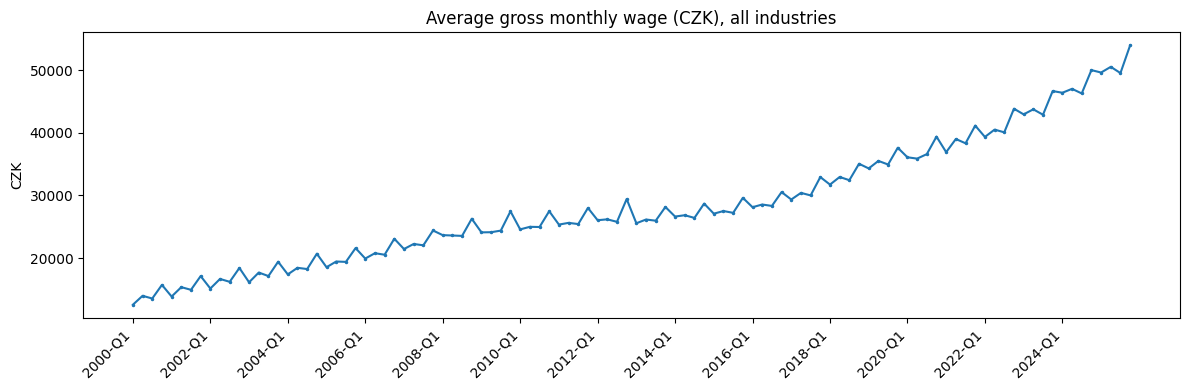

In [6]:
import matplotlib.pyplot as plt

wages = df[df["stapro"].str.contains("mzda", case=False, na=False)].copy()

# Combine year + quarter into a single time axis
wages["time"] = wages["year"].astype(str) + "-Q" + wages["quarter"].astype(str)

# Aggregate across industries (national average is typosoby == "přepočtený")
avg = (
    wages[wages["typosoby"] == "přepočtený"]
    .groupby("time")["value"]
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
avg.plot(ax=ax, marker=".", markersize=3)
ax.set_title("Average gross monthly wage (CZK), all industries")
ax.set_xlabel("")
ax.set_ylabel("CZK")
# Show only every 8th label to avoid clutter
ticks = range(0, len(avg), 8)
ax.set_xticks(ticks)
ax.set_xticklabels([avg.index[i] for i in ticks], rotation=45, ha="right")
fig.tight_layout()
plt.show()

## 4. Another dataset — Consumer Price Index

Dataset **010022** has monthly CPI data. This demonstrates a different data shape — monthly, no quarter column, with a `ucel` (purpose/category) dimension.

In [7]:
cpi = czso.get_table("010022")
print(f"Shape: {cpi.shape}")
print(f"Columns: {list(cpi.columns)}")
cpi.head()

Shape: (17004, 10)
Columns: ['value', 'ucel_tep', 'mesic', 'year', 'obdobiod', 'obdobido', 'bazobdobiod', 'bazobdobido', 'ucel', 'casz']


,value,ucel_tep,mesic,year,obdobiod,obdobido,bazobdobiod,bazobdobido,ucel,casz
0,104.0,ECOICOP,11,2025,2024-12-01,2025-11-30,2023-12-01,2024-11-30,"Alkoholické nápoje, tabák a narkotika",stejných 12 měsíců předchozího roku
1,103.7,ECOICOP,11,2025,2024-12-01,2025-11-30,2023-12-01,2024-11-30,Rekreace a kultura,stejných 12 měsíců předchozího roku
2,101.0,ECOICOP,11,2025,2025-11-01,2025-11-30,2024-11-01,2024-11-30,"Bytové vybavení, zařízení domácnosti; opravy",stejné období předchozího roku
3,103.7,ECOICOP,11,2025,2025-11-01,2025-11-30,2024-11-01,2024-11-30,Rekreace a kultura,stejné období předchozího roku
4,99.7,ECOICOP,11,2025,2025-11-01,2025-11-30,2025-10-01,2025-10-31,Komunikace,předchozí období


In [8]:
# Unique CPI categories
categories = cpi["ucel"].dropna().unique()
print(f"{len(categories)} categories, e.g.:")
for cat in sorted(categories)[:10]:
    print(f"  • {cat}")

19 categories, e.g.:
  • Alkoholické nápoje, tabák a narkotika
  • Alkoholické nápoje, tabák a narkotika
  • Bydlení, voda, energie, paliva
  • Bytové vybavení, zařízení domácnosti; opravy
  • Doprava
  • Komunikace
  • Odívání a obuv
  • Odívání a obuv
  • Ostatní výrobky a služby
  • Ostatní zboží a služby


## 5. Dataset metadata (without downloading data)

`get_dataset_metadata()` returns the JSON metadata for a dataset — useful for inspecting resources, tags, and temporal coverage before downloading.

In [9]:
meta = czso.get_dataset_metadata("110079")

result = meta["result"]
print(f"Title:      {result['title']}")
print(f"Frequency:  {result['frequency']}")
print(f"Period:     {result['temporal_start']} → {result['temporal_end']}")
print(f"Tags:       {[t['name'] for t in result['tags']]}")
print(f"Resources:  {len(result['resources'])}")
for r in result["resources"]:
    print(f"  • {r['format']} — {r['url'][:80]}...")

Title:      Zaměstnanci a průměrné hrubé měsíční mzdy podle odvětví
Frequency:  R/P3M
Period:     2000-01-01 → 2025-12-31
Tags:       ['Mzda', 'průměrná mzda', 'počet zaměstnanců', 'zaměstnanec', 'odvětví.']
Resources:  1
  • text/csv — https://csu.gov.cz/docs/107508/a3ee7532-de57-d1cb-c63b-90cec9a347a1/110079-25dat...


## 6. Codelists (číselníky)

CZSO publishes standardized codelists (classification tables). Codelist **100** contains the 14 Czech regions (kraje).

In [10]:
regions = czso.get_codelist(100)
print(f"Shape: {regions.shape}")
regions[["chodnota", "zkrtext", "text", "cznuts"]].head(15)

Shape: (15, 11)


,chodnota,zkrtext,text,cznuts
0,3000,Extra-Regio,Extra-Regio,CZZZZ
1,3018,Hl. m. Praha,Hlavní město Praha,CZ010
2,3026,Středočeský kraj,Středočeský kraj,CZ020
3,3034,Jihočeský kraj,Jihočeský kraj,CZ031
4,3042,Plzeňský kraj,Plzeňský kraj,CZ032
5,3051,Karlovarský kraj,Karlovarský kraj,CZ041
6,3069,Ústecký kraj,Ústecký kraj,CZ042
7,3077,Liberecký kraj,Liberecký kraj,CZ051
8,3085,Královéhradecký kraj,Královéhradecký kraj,CZ052
9,3093,Pardubický kraj,Pardubický kraj,CZ053


### Relational codelists

Pass a tuple to get a mapping between two codelists. `(100, 43)` maps regions → municipalities:

In [11]:
rel = czso.get_codelist((100, 43))
print(f"{len(rel)} region→municipality links")
rel[["text1", "text2"]].head(10)

6258 region→municipality links


,text1,text2
0,Hlavní město Praha,Praha
1,Středočeský kraj,Žitovlice
2,Středočeský kraj,Zápy
3,Středočeský kraj,Drnek
4,Středočeský kraj,Kamenný Most
5,Středočeský kraj,Lhota
6,Středočeský kraj,Hobšovice
7,Středočeský kraj,Malé Přítočno
8,Středočeský kraj,Dolany
9,Středočeský kraj,Polní Voděrady


## Further resources

- 📦 **Package**: [github.com/Marigold/czso](https://github.com/Marigold/czso)
- 🤖 **MCP server** (for AI assistants): [mcp-csu](https://github.com/reloadcz/mcp-csu) — accesses the newer DataStat API
- 📊 **R package** (inspiration): [petrbouchal/czso](https://github.com/petrbouchal/czso)